# 02. EDA and Previous Applications

У цьому ноутбуці виконую EDA клієнтських сегментів та аналіз історії попередніх заявок.

Для аналізу використовую підготовлені файли `app_clean.csv` та `prev_clean.csv`, які були створені в ноутбуці `01_data_preparation.ipynb`.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Завантаження підготовлених даних 

app_clean = pd.read_csv("../data/processed/app_clean.csv")
prev_clean = pd.read_csv("../data/processed/prev_clean.csv")

print(f"app_clean shape: {app_clean.shape}")
print(f"prev_clean shape: {prev_clean.shape}")

app_clean shape: (307511, 129)
prev_clean shape: (1670214, 37)


### Helper functions

In [3]:
# Функція для додавання підписів до barplot

def add_bar_labels(ax, data, value_col, count_col=None, offset=0.5):
    for i, row in data.reset_index(drop=True).iterrows():
        if count_col:
            label = (
                f'{row[value_col]:.2f}%\n'
                f'(n={int(row[count_col]):,})'
            ).replace(",", " ")
        else:
            label = f'{row[value_col]:.2f}%'

        ax.text(
            i,
            row[value_col] + offset,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )

## 6. Exploratory Data Analysis (EDA)

Мета цього етапу — дослідити основні закономірності в даних і відповісти на бізнес-питання про ризик дефолту клієнтів.

У цьому блоці використовую очищену робочу таблицю `app_clean`, у якій уже створені додаткові ознаки для аналізу фінансового навантаження клієнтів.

Перші питання для аналізу:

1. Яка частка клієнтів допустила дефолт?
2. Які клієнтські сегменти мають найвищий default rate?
3. Чи пов’язане співвідношення кредиту до доходу з дефолтом?

### 6.1. Яка частка клієнтів допустила дефолт?

На цьому етапі перевіряю розподіл клієнтів за цільовою змінною `TARGET`.

In [4]:
target_summary = (
    app_clean["TARGET"]
    .value_counts()
    .reset_index()
)

target_summary.columns = ["TARGET", "clients_count"]

target_summary["clients_percent"] = (target_summary["clients_count"] / target_summary["clients_count"].sum() * 100).round(2)

target_summary["target_label"] = target_summary["TARGET"].map({
    0: "No default",
    1: "Default"
})

target_summary = target_summary.sort_values("TARGET")
target_summary

,TARGET,clients_count,clients_percent,target_label
0,0,282686,91.93,No default
1,1,24825,8.07,Default


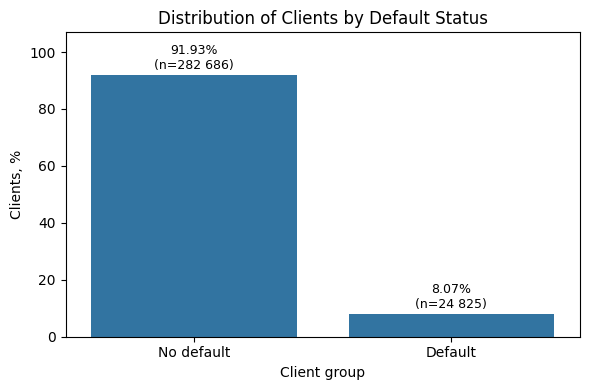

In [5]:
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=target_summary,
    x="target_label",
    y="clients_percent"
)

plt.title("Distribution of Clients by Default Status")
plt.xlabel("Client group")
plt.ylabel("Clients, %")
plt.ylim(0, target_summary["clients_percent"].max() + 15)

add_bar_labels(ax, target_summary, "clients_percent", "clients_count", offset=1)

plt.tight_layout()
plt.show()

Після етапу очищення розподіл цільової змінної `TARGET` не змінився: частка клієнтів із дефолтом становить **8.07%**, тоді як **91.93%** клієнтів не мали проблем із погашенням кредиту.

Дефолтна група є значно меншою за недефолтну. Тому в подальшому аналізі важливо дивитися не лише на кількість клієнтів у сегментах, а саме на `default rate`.

### 6.2. Які клієнтські сегменти мають найвищий default rate?

На цьому етапі аналізую, як ризик дефолту відрізняється між різними групами клієнтів.

Для аналізу використовую такі основні сегменти:

- вікова група;
- тип доходу / зайнятості;
- рівень освіти;
- сімейний статус.

Додатково перевіряю сегмент за наявністю дітей, але не виношу його в основну візуалізацію, оскільки різниця між групами є менш вираженою.

Основний показник для порівняння — `default rate`, тобто частка клієнтів із `TARGET = 1` у кожному сегменті.

In [6]:
# Функція для розрахунку default rate

def default_rate_by_segment(df, segment_col):
    result = (
        df.groupby(segment_col, observed=True)
        .agg(
            clients_count=("SK_ID_CURR", "count"),
            default_clients=("TARGET", "sum"),
            default_rate=("TARGET", "mean")
        )
        .reset_index()
    )
    
    result["default_rate"] = (result["default_rate"] * 100).round(2)
    
    return result.sort_values("default_rate", ascending=False)

In [7]:
# Формуємо одну зведену таблицю по сегментах

segment_columns = {
    "age_group": "Age group",
    "NAME_INCOME_TYPE": "Income type",
    "NAME_EDUCATION_TYPE": "Education level",
    "NAME_FAMILY_STATUS": "Family status",
    "children_group": "Children group"
}

segment_results = []

for col, label in segment_columns.items():
    temp = default_rate_by_segment(app_clean, col).copy()
    temp = temp.rename(columns={col: "segment_value"})
    temp["segment_type"] = label
    
    segment_results.append(
        temp[["segment_type", "segment_value", "clients_count", "default_clients", "default_rate"]]
    )

segment_summary = pd.concat(segment_results, ignore_index=True)

In [8]:
# Функція для форматування таблиць

def prepare_segment_view(df):
    df = df.copy()

    df["segment_type"] = pd.Categorical(
        df["segment_type"],
        categories=segment_columns.values(),
        ordered=True
    )

    df = df.sort_values(
        ["segment_type", "default_rate"],
        ascending=[True, False]
    )

    return df.set_index(["segment_type", "segment_value"])

In [9]:
# Сегменти з достатньою кількістю клієнтів для стабільнішої інтерпретації

main_segment_view = prepare_segment_view(
    segment_summary[segment_summary["clients_count"] >= 1000]
)

main_segment_view

clients_count  default_clients  \
segment_type    segment_value                                                   
Age group       20-29                                  44553             5111   
                30-39                                  82334             7891   
                40-49                                  76589             5869   
                50-59                                  68082             4185   
                60-69                                  35953             1769   
Income type     Working                               158774            15224   
                Commercial associate                   71617             5360   
                State servant                          21703             1249   
                Pensioner                              55362             2982   
Education level Lower secondary                         3816              417   
                Secondary / secondary special         218391            19524   
                Incomplete higher                      10277              872   
                Higher education                       74863             4009   
Family status   Civil marriage                         29775             2961   
                Single / not married                   45444             4457   
                Separated                              19770             1620   
                Married                               196432            14850   
                Widow                                  16088              937   
Children group  Has children                           92140             8216   
                No children                           215371            16609   

                                               default_rate  
segment_type    segment_value                                
Age group       20-29                                 11.47  
                30-39                                  9.58  
                40-49                                  7.66  
                50-59                                  6.15  
                60-69                                  4.92  
Income type     Working                                9.59  
                Commercial associate                   7.48  
                State servant                          5.75  
                Pensioner                              5.39  
Education level Lower secondary                       10.93  
                Secondary / secondary special          8.94  
                Incomplete higher                      8.48  
                Higher education                       5.36  
Family status   Civil marriage                         9.94  
                Single / not married                   9.81  
                Separated                              8.19  
                Married                                7.56  
                Widow                                  5.82  
Children group  Has children                           8.92  
                No children                            7.71

Для інтерпретації основних сегментів використовую групи з достатньою кількістю клієнтів (`clients_count >= 1000`). Це дозволяє уникнути висновків на основі дуже малих груп.

In [10]:
# Для малих груп окрема перевірка

small_segments_view = prepare_segment_view(
    segment_summary[segment_summary["clients_count"] < 1000]
)

small_segments_view

clients_count  default_clients  default_rate
segment_type    segment_value                                                
Income type     Maternity leave              5                2         40.00
                Unemployed                  22                8         36.36
                Businessman                 10                0          0.00
                Student                     18                0          0.00
Education level Academic degree            164                3          1.83
Family status   Unknown                      2                0          0.00

Окремо перевірено малі групи. Деякі з них мають високий `default rate`, але через дуже малу кількість клієнтів ці значення не варто використовувати як основний бізнес-висновок.

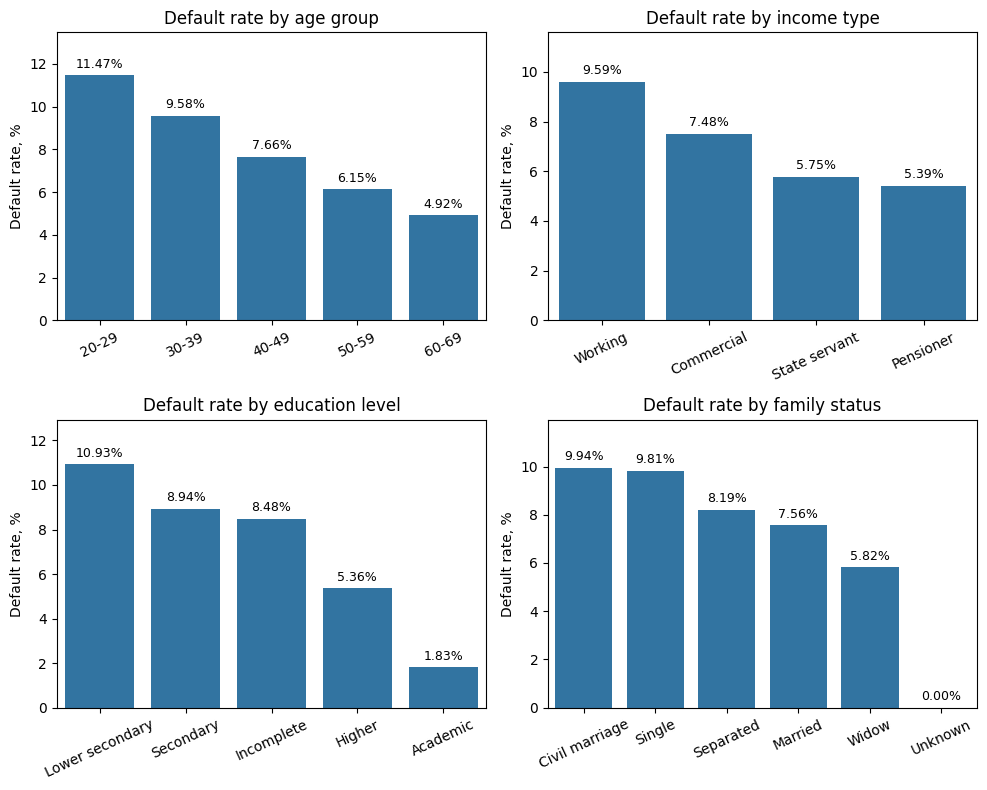

In [11]:
# Сегменти для візуалізації

plot_segments = [
    "age_group",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS"
]

titles = {
    "age_group": "Default rate by age group",
    "NAME_INCOME_TYPE": "Default rate by income type",
    "NAME_EDUCATION_TYPE": "Default rate by education level",
    "NAME_FAMILY_STATUS": "Default rate by family status"
}

short_labels = {
    "Secondary / secondary special": "Secondary",
    "Incomplete higher": "Incomplete",
    "Higher education": "Higher",
    "Lower secondary": "Lower secondary",
    "Academic degree": "Academic",
    "Commercial associate": "Commercial",
    "State servant": "State servant",
    "Single / not married": "Single",
    "Civil marriage": "Civil marriage"
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, segment in zip(axes, plot_segments):
    seg_df = default_rate_by_segment(app_clean, segment).copy()

    if segment == "NAME_INCOME_TYPE":
        seg_df = seg_df[seg_df["clients_count"] >= 1000]

    seg_df["plot_label"] = seg_df[segment].replace(short_labels)

    sns.barplot(
        data=seg_df,
        x="plot_label",
        y="default_rate",
        ax=ax
    )

    ax.set_title(titles[segment])
    ax.set_xlabel("")
    ax.set_ylabel("Default rate, %")
    ax.tick_params(axis="x", rotation=25)

    ax.set_ylim(0, seg_df["default_rate"].max() + 2)

    for i, row in seg_df.reset_index(drop=True).iterrows():
        ax.text(
            i,
            row["default_rate"] + 0.2,
            f'{row["default_rate"]:.2f}%',
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

Отримані графіки показують, що `default rate` відрізняється між клієнтськими сегментами.

Серед вікових груп найвищий рівень дефолту спостерігається у клієнтів віком **20–29 років** (11.47%), а далі показник поступово знижується з віком.

За рівнем освіти вищий `default rate` мають клієнти з **Lower secondary** та **Secondary / secondary special**, тоді як серед клієнтів із **Higher education** та **Academic degree** ризик дефолту нижчий.

За сімейним статусом відносно вищий рівень дефолту спостерігається у групах **Civil marriage** та **Single / not married**.

У `NAME_INCOME_TYPE` є категорії з дуже малою кількістю клієнтів: `Maternity leave`, `Unemployed`, `Student`, `Businessman`. Їхні значення `default rate` не варто інтерпретувати як основний висновок через малий розмір вибірки.

Для основних бізнес-висновків доцільно орієнтуватися на сегменти з достатньою кількістю спостережень.

### 6.3 Чи пов’язане співвідношення кредиту до доходу з дефолтом?

На цьому етапі аналізую, чи відрізняється `default rate` залежно від рівня кредитного навантаження клієнта.

Для цього використовую ознаку `credit_income_group`, створену на етапі Feature engineering на основі `credit_income_ratio`.

Це дозволяє порівняти рівень дефолту між групами клієнтів із різним співвідношенням суми кредиту до доходу.

In [12]:
# Рахуємо Default rate по групах

credit_income_summary = default_rate_by_segment(
    app_clean,
    "credit_income_group"
).copy()

credit_income_summary["credit_income_group"] = pd.Categorical(
    credit_income_summary["credit_income_group"],
    categories=["0-1", "1-2", "2-3", "3-5", "5-10", "10+"],
    ordered=True
)

credit_income_summary = credit_income_summary.sort_values("credit_income_group")

credit_income_summary

,credit_income_group,clients_count,default_clients,default_rate
0,0-1,14049,920,6.55
1,1-2,56439,4348,7.70
3,2-3,66165,5747,8.69
4,3-5,86751,7612,8.77
5,5-10,73070,5471,7.49
2,10+,11037,727,6.59


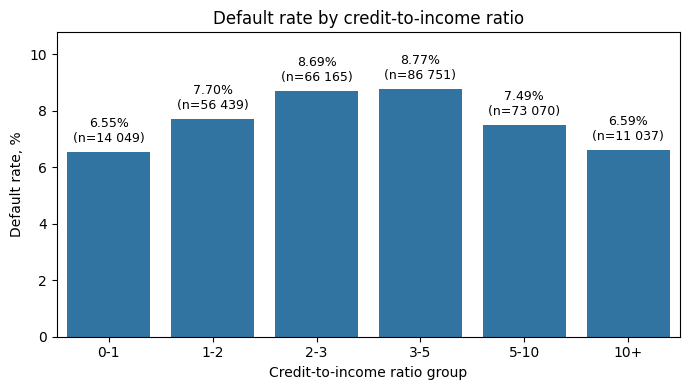

In [13]:
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=credit_income_summary,
    x="credit_income_group",
    y="default_rate"
)

plt.title("Default rate by credit-to-income ratio")
plt.xlabel("Credit-to-income ratio group")
plt.ylabel("Default rate, %")
plt.ylim(0, credit_income_summary["default_rate"].max() + 2)

add_bar_labels(ax, credit_income_summary, "default_rate", "clients_count", offset=0.25)

plt.tight_layout()
plt.show()

Графік показує, що зв’язок між `credit_income_ratio` та `default rate` не є повністю лінійним.

`n` показує кількість клієнтів у кожній групі.

Найвищий рівень дефолту спостерігається у групах із `credit_income_ratio` від **2 до 5**:
- `2–3` — **8.69%**;
- `3–5` — **8.77%**.

У крайніх групах `0–1` та `10+` кількість клієнтів менша, ніж у середніх групах, тому ці сегменти потрібно інтерпретувати обережніше.

Для груп із дуже високим співвідношенням кредиту до доходу (`5–10` та `10+`) `default rate` не зростає, а навпаки знижується. Тому не можна зробити висновок, що ризик дефолту автоматично збільшується разом із `credit_income_ratio`.

Цей показник варто використовувати як одну з ознак фінансового навантаження, але для повнішої оцінки ризику його потрібно аналізувати разом з іншими факторами.

## 7. Previous applications analysis

### 7.1. Який розподіл статусів попередніх заявок?

На цьому етапі аналізую статуси попередніх заявок клієнтів із таблиці `previous_application`.

Це допоможе зрозуміти, яка частка попередніх заявок була схвалена, відхилена, скасована або мала інший статус.

In [14]:
# Розподіл статусів попередніх заявок

prev_status_summary = (
    prev_clean["NAME_CONTRACT_STATUS"]
    .value_counts()
    .reset_index()
)

prev_status_summary.columns = ["contract_status", "applications_count"]

prev_status_summary["applications_percent"] = (
    prev_status_summary["applications_count"] 
    / prev_status_summary["applications_count"].sum() 
    * 100
).round(2)

prev_status_summary

,contract_status,applications_count,applications_percent
0,Approved,1036781,62.07
1,Canceled,316319,18.94
2,Refused,290678,17.40
3,Unused offer,26436,1.58


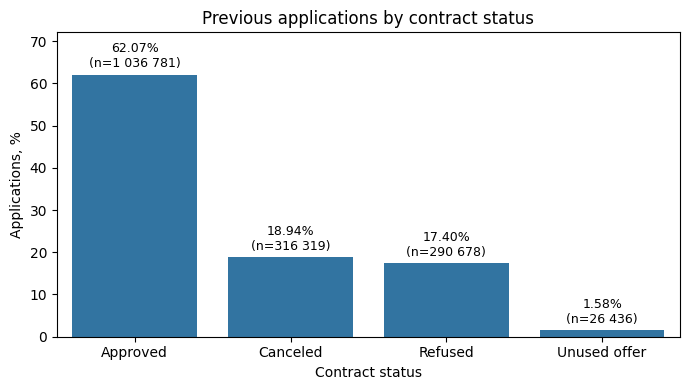

In [15]:
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=prev_status_summary,
    x="contract_status",
    y="applications_percent"
)

plt.title("Previous applications by contract status")
plt.xlabel("Contract status")
plt.ylabel("Applications, %")
plt.ylim(0, prev_status_summary["applications_percent"].max() + 10)

add_bar_labels(ax, prev_status_summary, "applications_percent", "applications_count", offset=1)

plt.tight_layout()
plt.show()

**Висновок:**

Більшість попередніх заявок мають статус `Approved` — **62.07%** від усіх попередніх заявок.

Частка скасованих заявок (`Canceled`) становить **18.94%**, а відхилених заявок (`Refused`) — **17.40%**. Тобто майже третина попередніх заявок не завершилась погодженням кредиту.

Статус `Unused offer` має невелику частку — **1.58%**, тому цей сегмент є менш поширеним.

На наступному етапі варто перевірити, чи пов’язаний статус попередніх заявок із поточним ризиком дефолту клієнта.

### 7.2 Чи пов’язаний статус попередніх заявок із поточним дефолтом?

На цьому етапі перевіряю, чи відрізняється `default rate` залежно від статусу попередніх заявок клієнта.

Оскільки один клієнт може мати кілька попередніх заявок, цей аналіз виконується на рівні попередніх заявок, пов’язаних із поточним клієнтом через `SK_ID_CURR`.

In [16]:
# Об'єднуємо попередні заявки з цільовою змінною з application_train

prev_with_target = prev_clean.merge(
    app_clean[["SK_ID_CURR", "TARGET"]],
    on="SK_ID_CURR",
    how="inner"
)

prev_with_target.shape

(1413701, 38)

Після об’єднання попередніх заявок із цільовою змінною розраховую `default rate` для кожного статусу попередньої заявки.

In [17]:
# Розрахунок default rate за статусом попередньої заявки

prev_default_by_status = (
    prev_with_target
    .groupby("NAME_CONTRACT_STATUS")
    .agg(
        applications_count=("SK_ID_PREV", "count"),
        default_applications=("TARGET", "sum"),
        default_rate=("TARGET", "mean")
    )
    .reset_index()
)

prev_default_by_status["default_rate"] = (
    prev_default_by_status["default_rate"] * 100
).round(2)

prev_default_by_status = prev_default_by_status.sort_values(
    "default_rate",
    ascending=False
)

prev_default_by_status

,NAME_CONTRACT_STATUS,applications_count,default_applications,default_rate
2,Refused,245390,29438,12.00
1,Canceled,259441,23800,9.17
3,Unused offer,22771,1879,8.25
0,Approved,886099,67243,7.59


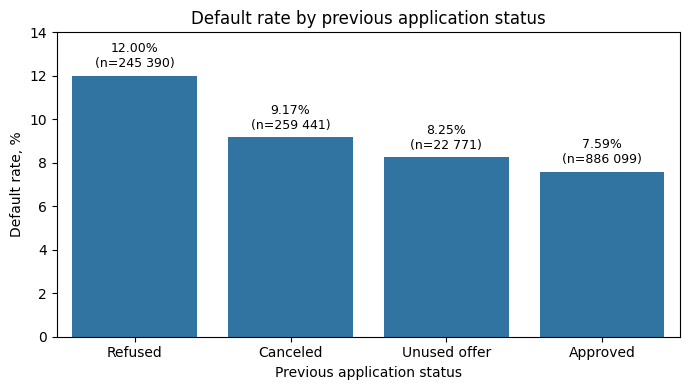

In [18]:
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=prev_default_by_status,
    x="NAME_CONTRACT_STATUS",
    y="default_rate"
)

plt.title("Default rate by previous application status")
plt.xlabel("Previous application status")
plt.ylabel("Default rate, %")
plt.ylim(0, prev_default_by_status["default_rate"].max() + 2)

add_bar_labels(ax, prev_default_by_status, "default_rate", "applications_count", offset=0.25)

plt.tight_layout()
plt.show()

**Висновок:**

Default rate відрізняється залежно від статусу попередньої заявки.

Найвищий рівень дефолту спостерігається серед попередніх заявок зі статусом `Refused` — **12.00%**. Це може свідчити, що попередні відмови пов’язані з вищим ризиковим профілем клієнта.

Для статусу `Canceled` default rate становить **9.17%**, для `Unused offer` — **8.25%**.

Найнижчий default rate мають попередні заявки зі статусом `Approved` — **7.59%**.

Оскільки один клієнт може мати кілька попередніх заявок, цей результат потрібно інтерпретувати як аналіз на рівні попередніх заявок, а не унікальних клієнтів.

### 7.3. Який тип попереднього кредитного продукту пов’язаний із вищим default rate?

На цьому етапі аналізую типи попередніх кредитних продуктів клієнтів із таблиці `previous_application`.

Спочатку перевіряю, які типи продуктів найчастіше зустрічаються у попередніх заявках, а далі порівнюю `default rate` для кожного типу продукту.

Це допоможе зрозуміти, чи може історія попереднього кредитного продукту бути пов’язана з поточним ризиком дефолту.

In [19]:
# Розподіл попередніх заявок за типом кредитного продукту

prev_product_summary = (
    prev_clean["NAME_CONTRACT_TYPE"]
    .value_counts()
    .reset_index()
)

prev_product_summary.columns = ["contract_type", "applications_count"]

prev_product_summary["applications_percent"] = (
    prev_product_summary["applications_count"]
    / prev_product_summary["applications_count"].sum()
    * 100
).round(2)

prev_product_summary

,contract_type,applications_count,applications_percent
0,Cash loans,747553,44.76
1,Consumer loans,729151,43.66
2,Revolving loans,193164,11.57
3,XNA,346,0.02


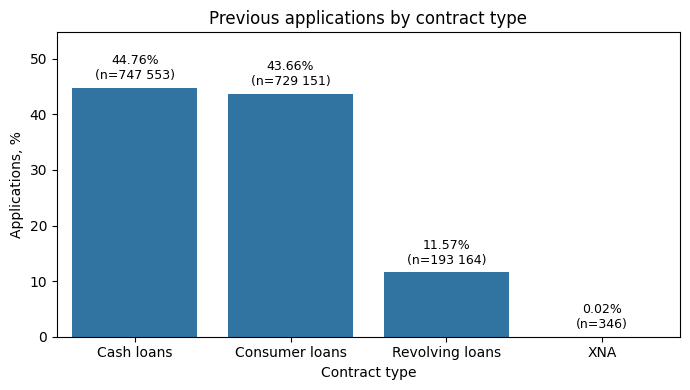

In [20]:
# Графік розподілу
    
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=prev_product_summary,
    x="contract_type",
    y="applications_percent"
)

plt.title("Previous applications by contract type")
plt.xlabel("Contract type")
plt.ylabel("Applications, %")
plt.ylim(0, prev_product_summary["applications_percent"].max() + 10)

add_bar_labels(ax, prev_product_summary, "applications_percent", "applications_count", offset=1)

plt.tight_layout()
plt.show()

In [21]:
# Default rate за типом попереднього кредитного продукту

prev_default_by_product = (
    prev_with_target
    .groupby("NAME_CONTRACT_TYPE")
    .agg(
        applications_count=("SK_ID_PREV", "count"),
        default_applications=("TARGET", "sum"),
        default_rate=("TARGET", "mean")
    )
    .reset_index()
)

prev_default_by_product["default_rate"] = (
    prev_default_by_product["default_rate"] * 100
).round(2)

prev_default_by_product = prev_default_by_product.sort_values(
    "default_rate",
    ascending=False
)

prev_default_by_product

,NAME_CONTRACT_TYPE,applications_count,default_applications,default_rate
3,XNA,313,63,20.13
2,Revolving loans,161368,16893,10.47
0,Cash loans,626764,57197,9.13
1,Consumer loans,625256,48207,7.71


Категорія `XNA` має дуже малу кількість заявок (313) і, ймовірно, є службовим або невідомим значенням, тому для основної візуалізації її прибираю.

In [22]:
# Для основної візуалізації прибираємо XNA

prev_default_by_product_main = prev_default_by_product[
    prev_default_by_product["NAME_CONTRACT_TYPE"] != "XNA"
].copy()

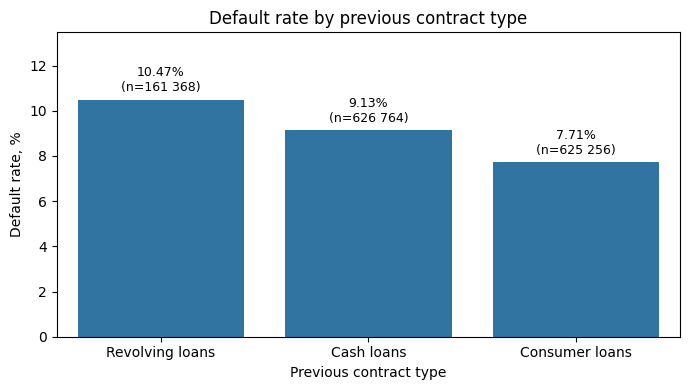

In [23]:
# Графік default rate

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=prev_default_by_product_main,
    x="NAME_CONTRACT_TYPE",
    y="default_rate"
)

plt.title("Default rate by previous contract type")
plt.xlabel("Previous contract type")
plt.ylabel("Default rate, %")
plt.ylim(0, prev_default_by_product_main["default_rate"].max() + 3)

add_bar_labels(ax, prev_default_by_product_main, "default_rate", "applications_count", 0.25)

plt.tight_layout()
plt.show()

**Висновок:**

У попередніх заявках найчастіше зустрічаються `Cash loans` (**44.76%**) та `Consumer loans` (**43.66%**). `Revolving loans` становлять меншу частку — **11.57%**.

За рівнем дефолту найвищий `default rate` серед основних типів попередніх продуктів мають `Revolving loans` — **10.47%**. Для `Cash loans` показник становить **9.13%**, а для `Consumer loans` — **7.71%**.

Категорія `XNA` має найвищий `default rate`, але містить дуже малу кількість заявок і є службовим/невідомим значенням, тому її не варто використовувати як основний бізнес-висновок.

Отже, тип попереднього кредитного продукту може бути пов’язаний із поточним ризиком дефолту, особливо якщо в історії клієнта були `Revolving loans`.

### 7.4 Чи пов’язаний offer gap у попередніх заявках із поточним дефолтом?

На цьому етапі аналізую різницю між запитаною сумою попередньої заявки (`AMT_APPLICATION`) та погодженою сумою кредиту (`AMT_CREDIT`).

Для аналізу використовую лише попередні заявки зі статусом `Approved`, оскільки саме для них погоджена сума кредиту є найбільш змістовною.

Мета — перевірити, чи відрізняється `default rate` залежно від того, чи була погоджена сума меншою, рівною або більшою за запитану.

In [24]:
# Підготовка даних для аналізу offer gap

prev_offer_gap = prev_with_target[
    (prev_with_target["NAME_CONTRACT_STATUS"] == "Approved")
    & (prev_with_target["AMT_APPLICATION"].notna())
    & (prev_with_target["AMT_CREDIT"].notna())
    & (prev_with_target["AMT_APPLICATION"] > 0)
].copy()

prev_offer_gap["offer_gap"] = (
    prev_offer_gap["AMT_CREDIT"] - prev_offer_gap["AMT_APPLICATION"]
)

prev_offer_gap["offer_gap_group"] = np.select(
    [
        prev_offer_gap["offer_gap"] < 0,
        prev_offer_gap["offer_gap"] == 0,
        prev_offer_gap["offer_gap"] > 0
    ],
    [
        "Credit lower than requested",
        "Credit equal to requested",
        "Credit higher than requested"
    ],
    default="Other"
)

prev_offer_gap[
    [
        "SK_ID_PREV",
        "SK_ID_CURR",
        "AMT_APPLICATION",
        "AMT_CREDIT",
        "offer_gap",
        "offer_gap_group",
        "TARGET"
    ]
].head()

,SK_ID_PREV,SK_ID_CURR,AMT_APPLICATION,AMT_CREDIT,offer_gap,offer_gap_group,TARGET
0,2030495,271877,17145.0,17145.0,0.0,Credit equal to requested,0
1,2802425,108129,607500.0,679671.0,72171.0,Credit higher than requested,0
2,2523466,122040,112500.0,136444.5,23944.5,Credit higher than requested,0
3,2819243,176158,450000.0,470790.0,20790.0,Credit higher than requested,0
5,1383531,199383,315000.0,340573.5,25573.5,Credit higher than requested,0


In [25]:
# Default rate за групами offer gap

offer_gap_summary = (
    prev_offer_gap
    .groupby("offer_gap_group")
    .agg(
        applications_count=("SK_ID_PREV", "count"),
        default_applications=("TARGET", "sum"),
        default_rate=("TARGET", "mean")
    )
    .reset_index()
)

offer_gap_summary["default_rate"] = (
    offer_gap_summary["default_rate"] * 100
).round(2)

offer_gap_order = [
    "Credit lower than requested",
    "Credit equal to requested",
    "Credit higher than requested"
]

offer_gap_summary["offer_gap_group"] = pd.Categorical(
    offer_gap_summary["offer_gap_group"],
    categories=offer_gap_order,
    ordered=True
)

offer_gap_summary = (
    offer_gap_summary
    .sort_values("offer_gap_group")
    .reset_index(drop=True)
)

offer_gap_summary

,offer_gap_group,applications_count,default_applications,default_rate
0,Credit lower than requested,280404,18859,6.73
1,Credit equal to requested,163827,12764,7.79
2,Credit higher than requested,402384,32584,8.10


In [26]:
# Скорочуємо назви груп для графіка

offer_gap_plot = offer_gap_summary.assign(
    offer_gap_group_short=offer_gap_summary["offer_gap_group"].astype(str).replace({
        "Credit lower than requested": "Lower",
        "Credit equal to requested": "Equal",
        "Credit higher than requested": "Higher"
    })
)

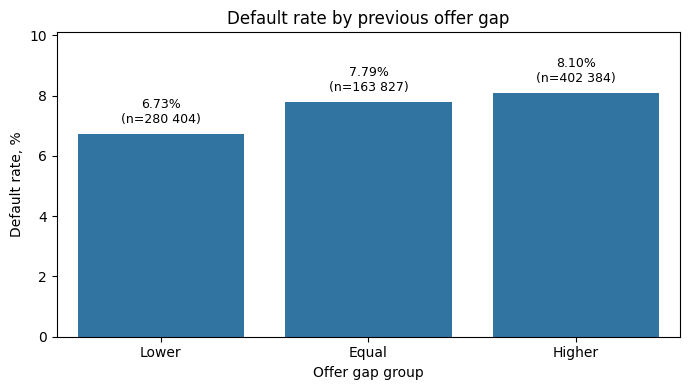

In [27]:
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=offer_gap_plot,
    x="offer_gap_group_short",
    y="default_rate"
)

plt.title("Default rate by previous offer gap")
plt.xlabel("Offer gap group")
plt.ylabel("Default rate, %")
plt.ylim(0, offer_gap_plot["default_rate"].max() + 2)

add_bar_labels(
    ax,
    offer_gap_plot,
    "default_rate",
    "applications_count",
    0.25
)

plt.tight_layout()
plt.show()

Для візуалізації групи `offer_gap` скорочено до `Lower`, `Equal` та `Higher`, де вони означають відповідно: погоджена сума нижча, дорівнює або вища за запитану.

**Висновок:**

`default rate` дещо відрізняється залежно від `offer gap` у попередніх погоджених заявках.

Найнижчий рівень дефолту спостерігається у групі, де погоджена сума була меншою за запитану — **6.73%**.

Для заявок, де погоджена сума дорівнювала запитаній, `default rate` становить **7.79%**.

Найвищий показник спостерігається у групі, де погоджена сума була більшою за запитану — **8.10%**.

Різниця між групами не є дуже великою, але результат може свідчити, що більший погоджений кредит відносно запитаної суми може бути пов’язаний із трохи вищим ризиком дефолту.

Цю ознаку варто враховувати як додатковий фактор, але не як самостійний головний індикатор ризику.

**Загальний висновок по блоку Previous applications analysis:**

Аналіз попередніх заявок показав, що кредитна історія клієнта у межах попередніх заявок може бути корисною для оцінки ризику дефолту.

Вищий `default rate` спостерігається для клієнтів, пов’язаних із попередніми заявками зі статусом `Refused`, а також для попередніх продуктів типу `Revolving loans`.

Також було помічено, що група, де погоджена сума кредиту була більшою за запитану, має трохи вищий `default rate`, ніж групи з меншою або рівною погодженою сумою.

Отже, статус попередньої заявки, тип попереднього продукту та `offer gap` можуть бути корисними ознаками для подальшого аналізу, бізнес-висновків і ML-блоку.

## Summary

У цьому ноутбуці виконано EDA клієнтських сегментів та аналіз попередніх заявок.

Результати показали, що `default rate` відрізняється між клієнтськими групами, а історія попередніх заявок може бути корисною для оцінки ризику дефолту.

Далі ці результати будуть використані для SQL-аналізу, статистичної перевірки та підготовки Tableau dashboard.